# Imports

In [1]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from importlib import reload
import starships.plotting_fcts as pf 

import astropy.units as u
import astropy.constants as const

from starships import homemade as hm
from itertools import product

from scipy.interpolate import interp1d

In [3]:
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [4]:
# %matplotlib notebook
%matplotlib inline

# Setting plot parameters
couleurs = hm.get_colors('magma', 50)[5:-2]

# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler(color=hm.get_colors('magma', 50))
# ex : list_of_color = [(i,0,0) for i in np.arange(10)/10]

In [5]:
from starships.correlation_class import Correlations
import starships.correlation_class as cc
from starships import correlation as corr

cc=reload(cc)

import starships.planet_obs as pl_obs
from starships.planet_obs import Observations, Planet

pl_obs=reload(pl_obs)

# Read pre-generated model

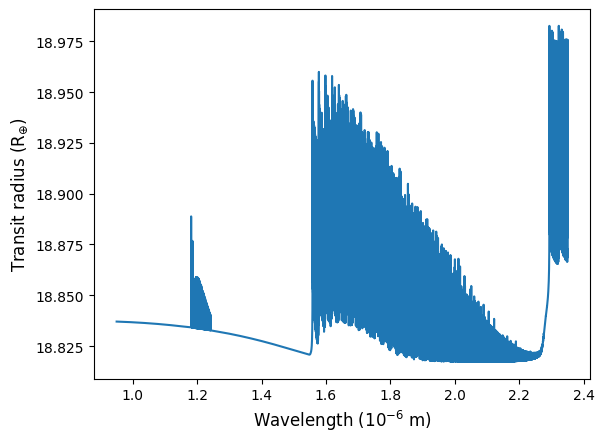

In [30]:
#-------------------------------------------------------------#
# Where to find the models
model_directory = "/home/mathisb/Github/HRS_models/"

# Name of npz model file
model_filename = "prt_model_WASP-33b_CO_vstellar.npz"
#-------------------------------------------------------------#

model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

# Plot it
plt.plot(wave_mod, model_spec)

plt.xlabel('Wavelength ($10^{-6}$ m)', fontsize=12)
plt.ylabel(r'Transit radius ($\rm R_{\oplus}$)', fontsize=12)
plt.show()

### Add noise to model if needed

In [7]:
use_noisy_model = False

if use_noisy_model:
    noise_added = 0.01 * np.random.rand(len(model_spec))
    model_spec = model_spec + noise_added # - np.mean(noise_added)

    plt.plot(wave_mod, model_spec)
    plt.ylim(1.07,1.19)
    plt.show()

    model_filename = "prt_model_TRAPPIST-1b_noisybarerock_v01.npz"  # make sure the code doesn't fetch the noiseless barerock model

# Get planet info and determine directories to use

In [31]:
#-----------------------------------------------------------#

# Planet parameters and reduction details

pl_name = 'WASP-33 b'

visit_name = '2019-10-07'
reduc_version = 'vKeepMasterOut'
instrument = "SPIRou"

#-----------------------------------------------------------#

ap = 0.0259*u.au
R_star = (ap/3.69).to(u.R_sun)
R_pl = (0.1143*R_star).to(u.R_jup)
M_star = 1.561*const.M_sun

pl_kwargs = {'M_star': M_star, 
            'R_star': R_star,
            'ap': ap,
            'R_pl': R_pl}

planet_obj=Planet(pl_name, **pl_kwargs)

INFO:starships.planet_obs:Getting WASP-33 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [3.28087629e+30] kg to 3.1039078081596574e+30 kg
INFO:starships.planet_obs:It became [3.10390781e+30] kg
INFO:starships.planet_obs:Changing R_star from [1.11312e+09] m to 1.5093042904789116 solRad
INFO:starships.planet_obs:It became [1.05002299e+09] m
INFO:starships.planet_obs:Changing ap from [3.8222256e+09] m to 0.0259 AU
INFO:starships.planet_obs:It became [3.87458485e+09] m
INFO:starships.planet_obs:Changing R_pl from [1.07023524e+08] m to 1.6787560610346646 jupiterRad
INFO:starships.planet_obs:It became [1.20017628e+08] m


In [33]:
#-----------------------------------------------------------#
# Where to find the reductions
reduc_in_scratch = True  # the reductions are in the scratch directory (True) or in the home directory (False)

# Indicate which reductions to use (sequence files)
filename_list = [
                f"sequence_0-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_1-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_2-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_3-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_4-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_5-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_6-pc_mask_wings97_data_trs_{visit_name}.npz",
                ]
#-----------------------------------------------------------#

# Directory where the reductions are
if reduc_in_scratch:
    base_dir = Path(os.environ['SCRATCH'])
else:
    base_dir = Path.home() / "Github"

pl_name_fname = ''.join(pl_name.split())

reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduc_version}')

print("Reduction directory is:", reduc_dir)

Reduction directory is: /scratch/mathisb/HRS_reductions/SPIRou/WASP-33b/2019-10-07/vKeepMasterOut


In [34]:
#-----------------------------------------------#
# Where to output the correlations
output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
#-----------------------------------------------#

# Create output directory if it does not exist
output_dir.parent.mkdir(parents=True, exist_ok=True)

print("Correlations directory is:", output_dir)

Correlations directory is: /scratch/mathisb/HRS_correlations/SPIRou/WASP-33b/2019-10-07/KeepMasterOut


# Correlations

In [35]:
#----------------------------------------------------------#
# Cross-correlation axes
step_RV_inj = 2.14  # 2 times the resolution of SPIRou in km/s
corrRV0 = np.arange(-150, 150, step_RV_inj)  # x axis (Vsys)

kind_trans = 'emission'  # emission or transmission
#----------------------------------------------------------#

# GENERATE KP/VSYS MAP
model_name = model_filename[10:][:-4]

n_pc_list = []
mask_wings_list = []
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()

for filename in filename_list:
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    # Generate Kp 
    Kp_array = np.array([obs.Kp.value]) 
        
    n_pc = int(obs.params[5])
    n_pc_list.append(n_pc)
    
    mask_wings = int(obs.params[1] * 100)  # in percent
    mask_wings_list.append(mask_wings)
    
    out_filename = f'{Path(filename).stem}_ccf_logl_seq_{model_name}'
    
    try:
        # Check if already generated
        saved_values = np.load(output_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
    except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs,
                            'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
    
        corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map,
                           wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    
    all_obs[(n_pc, mask_wings)] = obs
    all_ccf_map[(n_pc, mask_wings)] = ccf_map
    all_logl_map[(n_pc, mask_wings)] = logl_map


[2454163.22367] d
Emission
Injecting model w/ alpha = ones
Starting with 0 PCs
Computing with
Saved correl at : /scratch/mathisb/HRS_correlations/SPIRou/WASP-33b/2019-10-07/KeepMasterOut/sequence_0-pc_mask_wings97_data_trs_2019-10-07_ccf_logl_seq_WASP-33b_CO_vstellar.npz


## Plots

Max value at 0 npc = -0.46712806693292047 at -6.6199965301465955 km/s
Max value at 0 npc = -0.46733235795882494 at -6.6199965301465955 km/s
Max value at 0 npc = -0.46733235795882494 at -6.6199965301465955 km/s
CCF SNR peak at Vrad*: [-0.46712807]
log(L) abs peak at Vrad*: [-2575160.94196053]
log_10(ΔBIC) peak at Vrad*: [-0.3463231]
[0.]
(38, 141)
(array([52, 53, 54]),)
In-transit t-val = -2.46 / p-val 1.62e-02 / sig = 2.14
Out-of-transit t-val = -4.94 / p-val 1.85e-05 / sig = 4.13


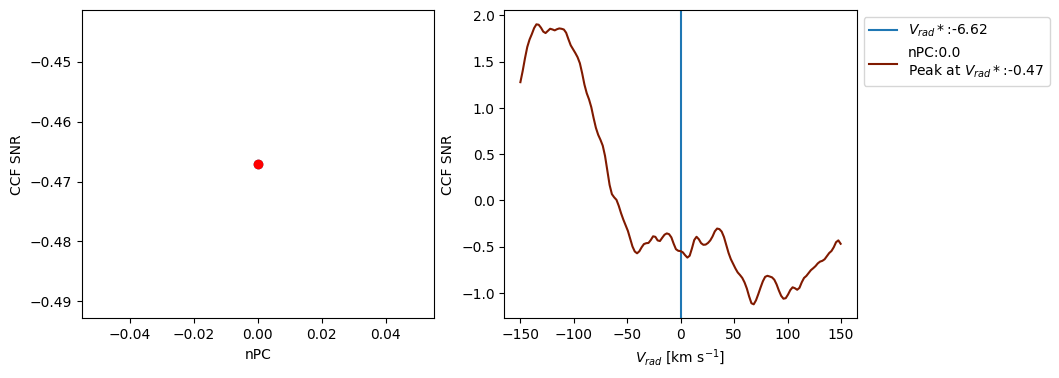

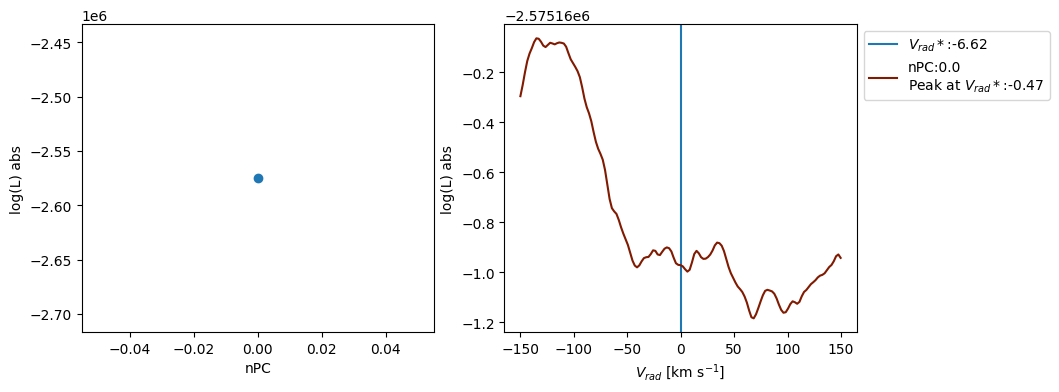

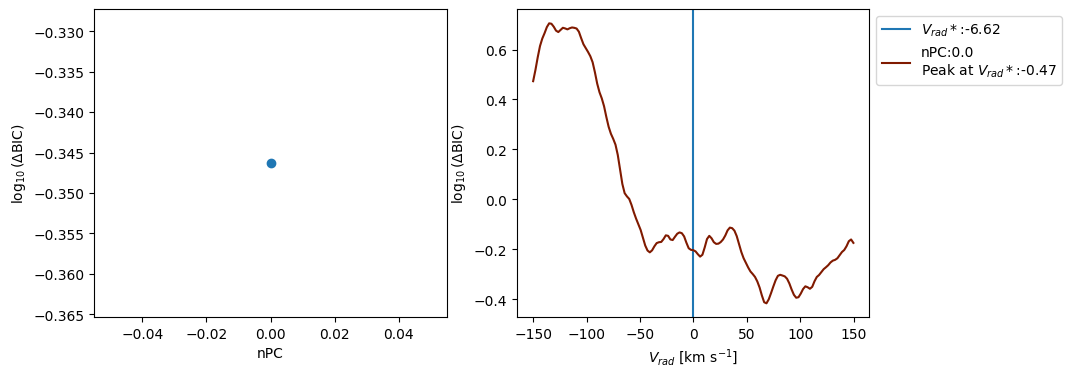

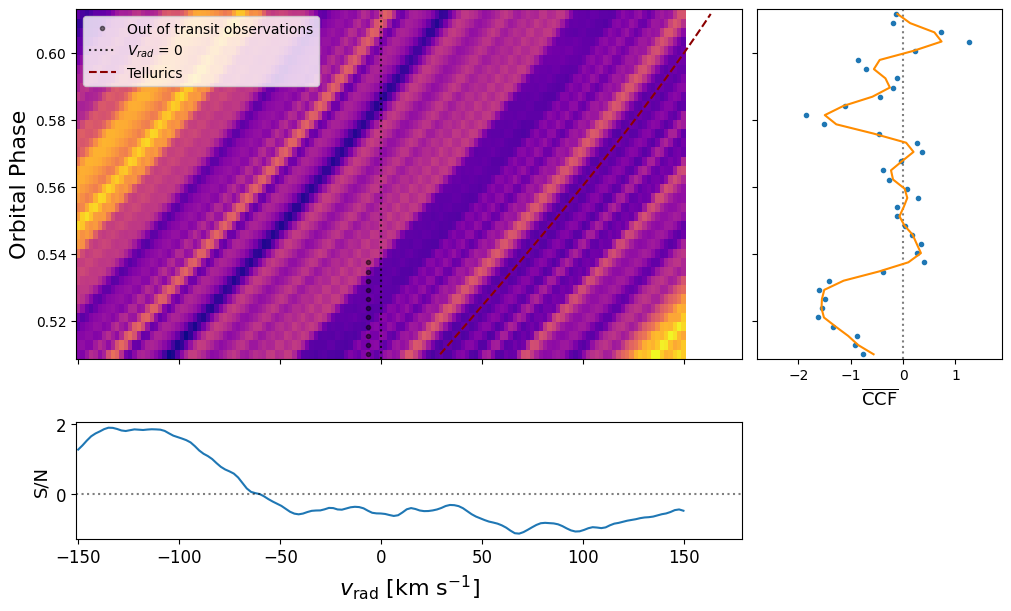

In [36]:
#----------------------------------------------#
# Indicate orders to use
nb_orders = 49  # number of orders in reduction

# orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25],
#                     [37,38,39], [46,47,48]]  # indices of orders that should not be used

# Use non-disgusting orders: delete [0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]
# Use only orders with CO2 features: delete [0,1,2,3,4,5,8,9], [11,12,13,14,15,22],[23,24,25,26,26,35,36], [37,38,39,45], [46,47,48]

# orders_to_delete = [[0], np.arange(10,27), np.arange(34,42), np.arange(43,49)] #custom - K stellar model
orders_to_delete = [np.arange(0,14), np.arange(18,31), [37,38,39], [45,46,47,48]] #for CO model at T_stellar

#----------------------------------------------#

order_indices = np.arange(nb_orders)

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    order_indices = np.setdiff1d(order_indices, elem)

n_pc_list = np.unique(n_pc_list)
mask_wings_list = np.unique(mask_wings_list)

id_pc0 = 0  # don't change

# Plot all ccf and logl as a function of pc
for mask_wings in mask_wings_list:
    ccf_maps_in = [all_ccf_map[(n_pc, mask_wings)] for n_pc in n_pc_list]
    ccf_maps_in = np.concatenate(ccf_maps_in, axis=-2)
    logl_maps_in = [all_logl_map[(n_pc, mask_wings)] for n_pc in n_pc_list]
    logl_maps_in = np.concatenate(logl_maps_in, axis=-2)
    obs = all_obs[(n_pc_list[0], mask_wings)]

    ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0,
                                        Kp_array, n_pc_list, orders=order_indices, id_pc0=id_pc0)

# # Print info about the plots
# print("\nInformation about the plots:\n" + cc.plot_ccflogl.__doc__ + "\n" + 
#       Correlations.plot_multi_npca.__doc__ + "\n" + Correlations.plot_PRF.__doc__)


### Define n_pc and mask_wings used in the next few plots

In [37]:
n_pc, mask_wings = 0, 97

#----------------------------

filename = f'sequence_{n_pc}-pc_mask_wings{mask_wings}_data_trs_{visit_name}.npz'

[2454163.22367] d
Emission
Max value at 0 npc = -0.46712806693292047 at -6.6199965301465955 km/s
Max value at 0 npc = -0.46733235795882494 at -6.6199965301465955 km/s
Max value at 0 npc = -0.46733235795882494 at -6.6199965301465955 km/s
CCF SNR peak at Vrad*: [-0.46712807]
log(L) abs peak at Vrad*: [-2575160.94196053]
log_10(ΔBIC) peak at Vrad*: [-0.3463231]
[0.]
(38, 141)
(array([52, 53, 54]),)
In-transit t-val = -2.46 / p-val 1.62e-02 / sig = 2.14
Out-of-transit t-val = -4.94 / p-val 1.85e-05 / sig = 4.13


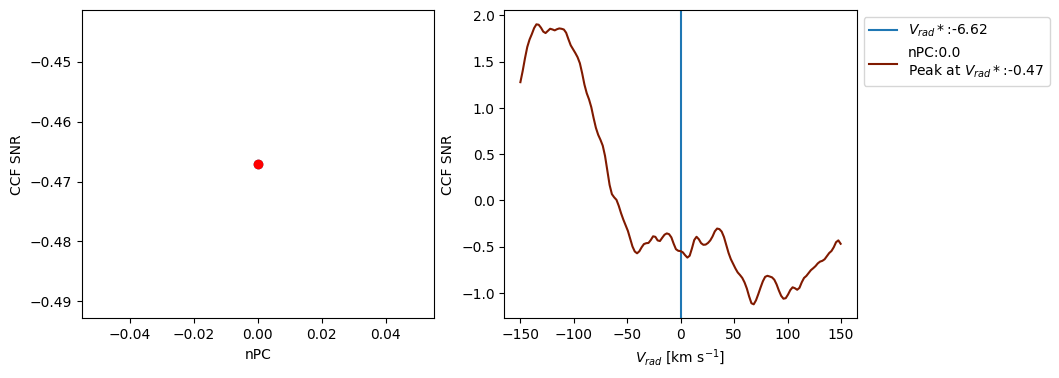

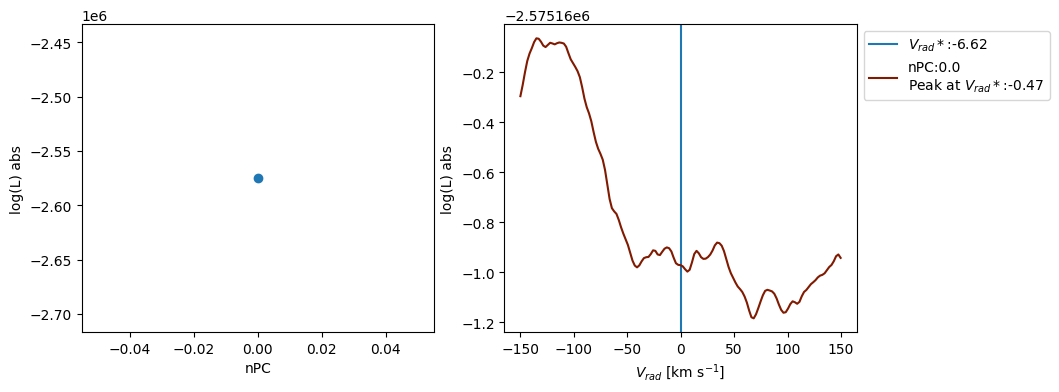

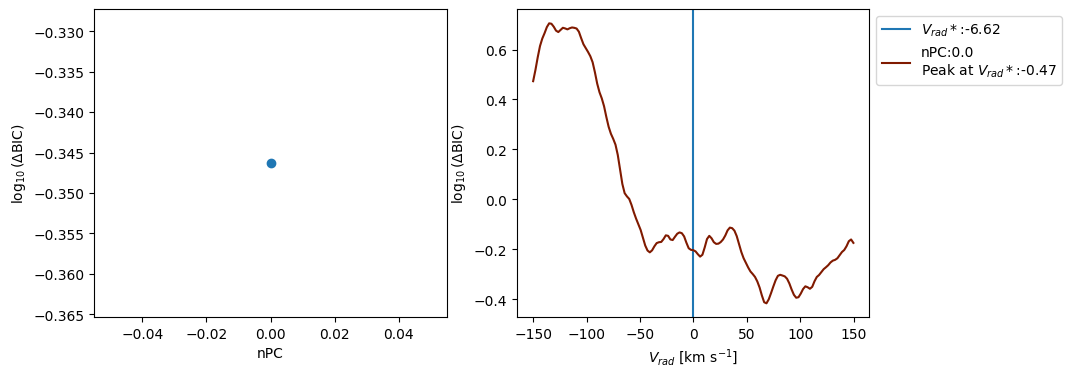

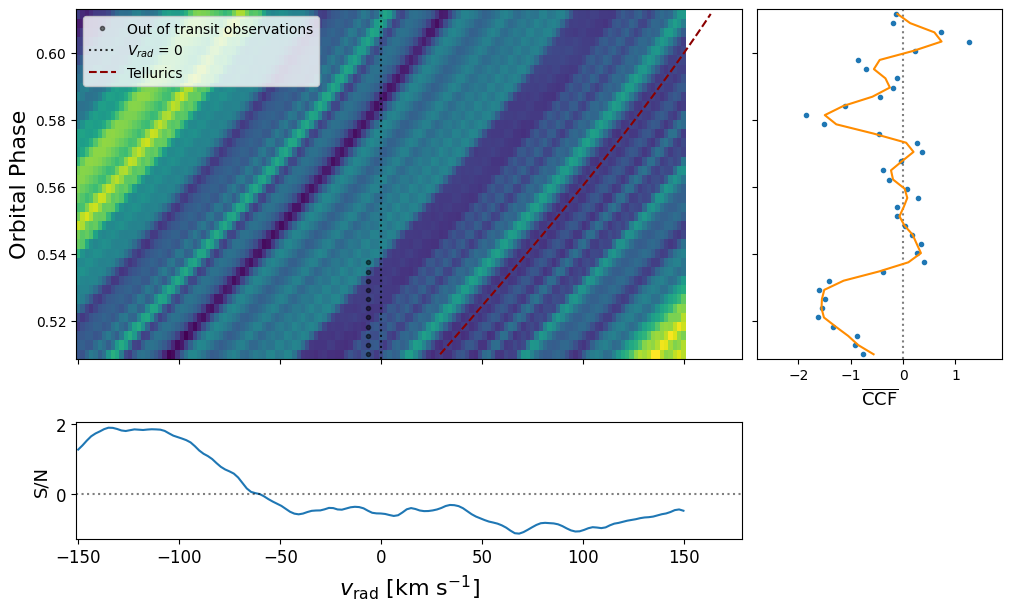

In [38]:
# Plot single ccf and logl

obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)

args = [all_something[(n_pc, mask_wings)]
        for all_something in [all_obs, all_ccf_map, all_logl_map]]
ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc], orders=order_indices, cmap="viridis")

T-val : Max value = -2.5 // Max position = -1.9
Histogram for Kp = 230.68 and RV = -6.62
-2.848834393332575 0.0056342858242271095 2.5342580453670567


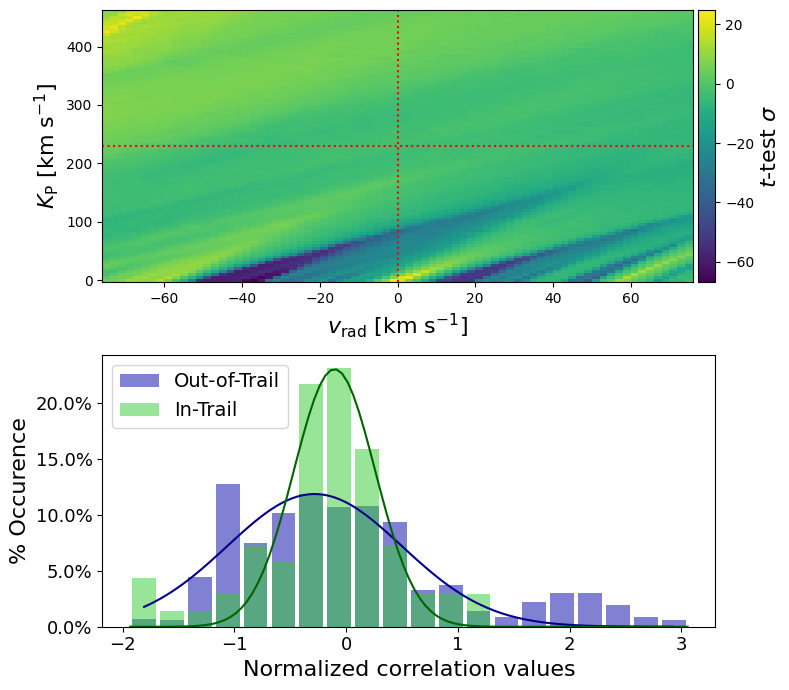

<Figure size 640x480 with 0 Axes>

In [39]:
# Generate the ttest map

ccf_obj.ttest_map(all_obs[(n_pc, mask_wings)], kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                  kp0=0, RV_limit=75, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=obs.iIn, equal_var=False)

# # Print info about the plots
# print("\nInformation about the plots:\n" + pf.plot_ttest_map_hist.__doc__)

In [1]:
# # Plot SCALED Kp/Vrad plot (good for science) with location of tellurics

# tr=all_obs[(n_pc, mask_wings)]
# cobj = ccf_obj
# t_value = cobj.ttest_map_tval

# t_value_scaled = t_value*(-3)/t_value.min()

# (t_in, p_in) = pf.plot_ttest_map_hist(tr, cobj.rv_grid, cobj.map_prf.copy(), 
#                                            cobj.ttest_map_kp, cobj.ttest_map_rv, 
#                                     t_value_scaled, cobj.ttest_map_params, 
#                               plot_trail=True, masked=True, ccf=cobj.map_prf.copy(),
#                               vrp=np.zeros_like(tr.vrp), RV=cobj.pos, hist=False,
#                                       show_max=False, show_rest_frame=False,
#                                     fig_name='', path_fig=None, orders=order_indices)
# # fig.get_axes()[0].text(-67.0, 300, r'H$_2$O', fontsize=16, bbox ={'facecolor':'white', 'alpha':0.8})
# fig = plt.gcf()
# ax = fig.axes

# pos_max = -3.2
# # - Lines enclosing the maximum -
# ax[0].axhline(tr.Kp.to(u.km / u.s).value, linestyle='--', alpha=0.7, color='r', 
#               xmin=0,xmax=hm.nearest(cobj.interp_grid, pos_max-20)/cobj.interp_grid.size )
# ax[0].axhline(tr.Kp.to(u.km / u.s).value, linestyle='--', alpha=0.7, color='r',
#               xmin=hm.nearest(cobj.interp_grid, pos_max+20)/cobj.interp_grid.size ,xmax=1) 
# ax[0].axvline(pos_max, linestyle='--', alpha=0.7, color='r', 
#                   ymin=0, ymax=(tr.Kp.value - 60)/cobj.ttest_map_kp[-1] )
# ax[0].axvline(pos_max, linestyle='--', alpha=0.7, color='r',
#                   ymin=(tr.Kp.value + 60)/cobj.ttest_map_kp[-1] , ymax=1)

# fig.set_size_inches(4.5,3)
# plt.tight_layout()
# #fig.savefig(data_path+'Figures/'+'t3_H2O_night.pdf', rasterize=True)

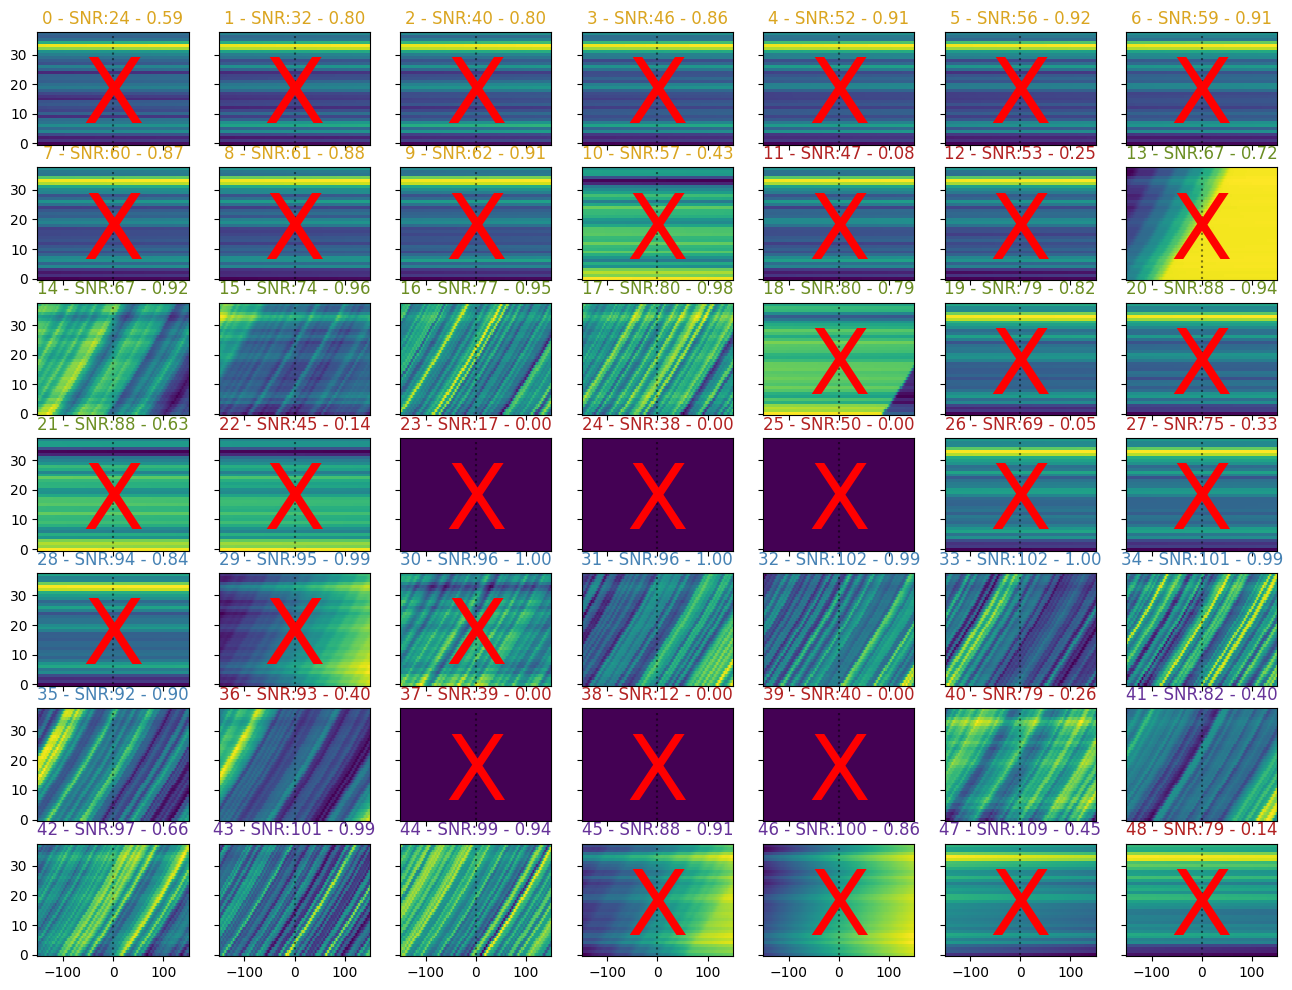

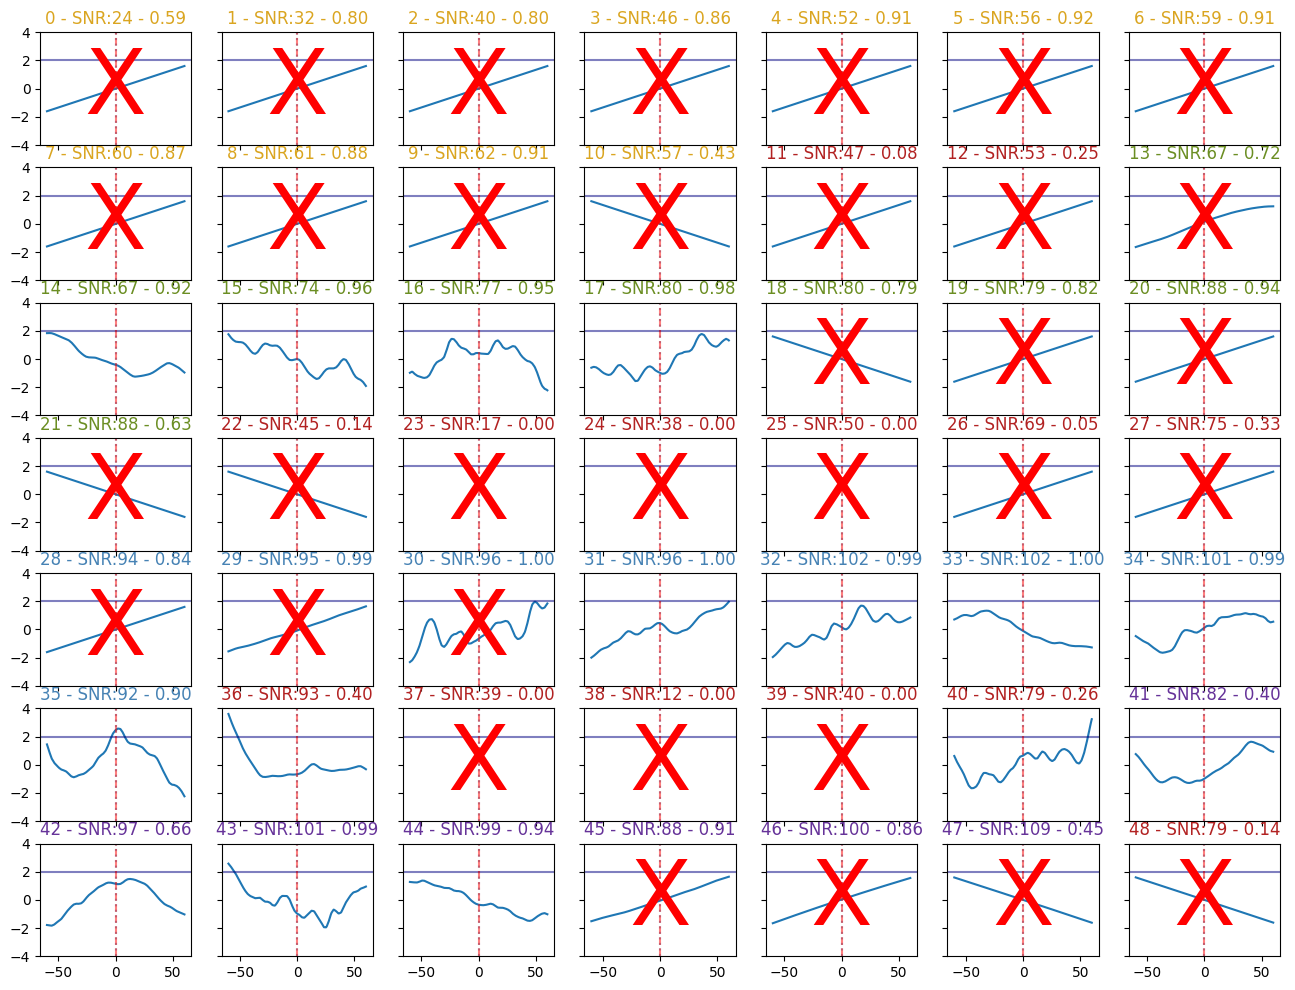

In [41]:
# Plot all orders

pf.plot_all_orders_correl(corrRV0,ccf_obj.data.squeeze(), all_obs[(n_pc, mask_wings)],
                                      icorr=None, logl=False, sharey=True,
                                      vrp=np.zeros_like(all_obs[(n_pc, mask_wings)].vrp),
                              RV_sys=0.0, vmin=None, vmax=None,
                                      vline=None, hline=2, kind='snr', return_snr=False, orders=order_indices)

In [ ]:
# PLOT THE MODEL ORDER BY ORDER

# Orders to plot
order_plot = [14]

#---------------------------------------------------------------


fct_model = interp1d(wave_mod, model_spec, kind='cubic')

for i_ord in order_plot:

    wv_ord = all_obs[(n_pc, mask_wings)].wv[i_ord]
    mask_ord = all_obs[(n_pc, mask_wings)].final.mask[0, i_ord]
    
    coeff = np.polyfit(wv_ord, fct_model(wv_ord), 1)
    model_ord = np.ma.array(fct_model(wv_ord), mask=mask_ord)
    
    plt.figure()
    poly_fct = np.poly1d(coeff)
    plt.plot(wv_ord, model_ord / poly_fct(wv_ord))
    plt.title("Order #" + str(i_ord))
    
    #plt.gca().twinx().plot(wv_ord, mask_ord, 'r')

# Combine visits

In [107]:
pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell

# To combine: visit name, reduction version, sequence file
file_arr = np.array([
                    ['1', '2019-06-14', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    # ['2', '2019-09-25', 'v006', 'sequence_0-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    # ['3', '2020-05-31', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    # ['4', '2020-08-04', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    # ['5', '2020-09-08', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    # ['6', '2020-09-20', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    # ['7', '2020-09-26', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    # ['8', '2020-09-29', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    ['9', '2021-10-21', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    # ['10', '2021-10-24', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    # ['11', '2021-10-27', 'v001', 'sequence_0-pc_mask_wings97_data_trs_2021-10-27.npz'],
                    ])


kind_trans = 'transmission'  # emission or transmission
ld_model = 'nonlinear'
coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients

# Cross-correlation axes
step_RV_inj = 2.14  # 2 times the resolution of SPIRou in km/s
corrRV0 = np.arange(-150, 150, step_RV_inj)  # x axis (Vsys)


#-----------------------------------------------------------------------------------------------------------


model_name = model_filename[10:][:-4]

combined_ccf = []
combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""

for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    version = reduc[2]
    fname = reduc[3]
    
    # Where to find the reductions
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{version}')
    
    # Where to find the correlations
    corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}')
    
    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj=Planet(pl_name, **pl_kwargs)
    
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    out_filename = f'{Path(fname).stem}_ccf_logl_seq_{model_name}'
    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
    except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
    
    
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    

    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)

all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposition times

all_visits_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits

pl_obs.log.setLevel("INFO")  # go back to normal log printing

[2458649.07123219] d
Transmission
[2459508.76250268] d
Transmission


In [ ]:
# Indicate orders to use
nb_orders = 49  # number of orders in reduction
orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25],
                    [37,38,39], [46,47,48]]  # indices of orders that should not be used

#-------------------------------------------------------

idx_orders = np.arange(nb_orders)

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    idx_orders = np.setdiff1d(idx_orders, elem)

    
# Generate Kp 
Kp_array = np.array([obs.Kp.value]) 

ccf_map = np.concatenate(combined_ccf)
logl_map = np.concatenate(combined_logl)


ccf_obj, logl_obj = cc.plot_ccflogl(all_visits, 
                                    ccf_map,
                                    logl_map,
                                    corrRV0, Kp_array, [1],
                                  # split_fig = [0,t1.n_spec,t1.n_spec+t2.n_spec],  # don't use if only doing combined
                                    orders=idx_orders
                                   )


ccf_obj.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0,
                  RV_limit=75, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False, 
                  )



t_value = ccf_obj.ttest_map_tval

(t_in, p_in), fig = pf.plot_ttest_map_hist(all_visits, ccf_obj.rv_grid, ccf_obj.map_prf.copy(), 
                                           ccf_obj.ttest_map_kp, ccf_obj.ttest_map_rv, 
                                    t_value*(-3)/t_value.min(), ccf_obj.ttest_map_params, 
                              plot_trail=True, masked=True, ccf=ccf_obj.map_prf.copy(),
                              vrp=np.zeros_like(all_visits.vrp), RV=ccf_obj.pos, hist=False,
                                    fig_name='', path_fig=None, cmap='viridis')


Max value at 1 npc = 2.419574544126516 at 4.273297402720372 km/s
Max value at 1 npc = 1.6657724862490955 at -1.2665331303446896 km/s
Max value at 1 npc = 1.6657724862490955 at -1.2665331303446896 km/s
CCF SNR peak at Vrad*: [2.41957454]
log(L) abs peak at Vrad*: [159182.75350653]
log_10(ΔBIC) peak at Vrad*: [43.23715727]
[0.]
(30, 141)
(array([57, 58, 59]),)
In-transit t-val = 3.46 / p-val 2.04e-03 / sig = 2.87
Out-of-transit t-val = -1.96 / p-val 5.40e-02 / sig = 1.61


In [ ]:
# SAVE COMBINED CORRELATION
#---------------------------

# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/')

# Create output directory if it does not exist
output_dir_comb.parent.mkdir(parents=True, exist_ok=True)

print("Combined correlations directory is:", output_dir_comb)


# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"

print(filename)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb)

### Sensitivity vs number of transits

#### Create lists of cross-correlation values

In [204]:
# nb_transits_list = []
# std_dev_list = []
# signal_str_list = []

#### Get cross-correlation values

In [205]:
# GET CCF VALUES FOR EACH Vrad
#-----------------------------

ccf_vals = ccf_obj.logl.squeeze()

nb_transits_list.append(len(file_arr))

In [206]:
# GET STD DEVIATION OF CCF OUTSIDE OF TRAIL
#------------------------------------------

# Get ccf values outside trail (v_rad = -150 to -100 and 100 to 150)
ccf_outside_trail = np.concatenate((ccf_vals[:24], ccf_vals[117:]), axis=0)

# Calculate std deviation
ccf_std_dev = np.std(ccf_outside_trail)
print(f"Standard deviation with {len(file_arr)} transits is", ccf_std_dev)

std_dev_list.append(ccf_std_dev)

Standard deviation with 3 transits is 0.0003909541842457857


In [207]:
# GET SIGNAL STRENGTH AT Vrad = 0
#------------------------------------------

# Get ccf values around Vrad = 0 (v_rad = -150 to -100 and 100 to 150)
ccf_at_zero = ccf_vals[68:73]

# Calculate mean signal
ccf_mean = np.mean(ccf_at_zero)
print(f"Mean ccf signal value with {len(file_arr)} transits is", ccf_mean)

signal_str_list.append(ccf_mean)

Mean ccf signal value with 3 transits is 0.0006959000867369133


(141,)
(48,)
(5,)


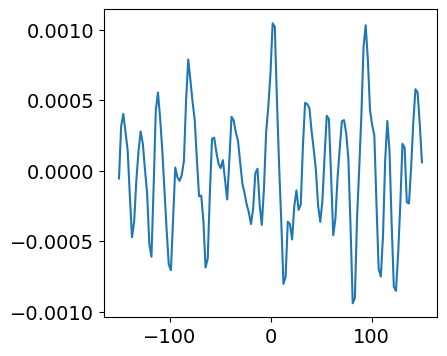

In [208]:
# Check that everything makes sense
print(np.shape(ccf_vals))
print(np.shape(ccf_outside_trail))
print(np.shape(ccf_at_zero))

plt.figure(figsize=(4.3,4))
plt.plot(corrRV0, ccf_vals)  # should look like the CCF SNR plot above
plt.show()

#### Plot cross-correlation values

In [209]:
plt.rcParams.update({'font.size': 14})  # increase label size in all plots

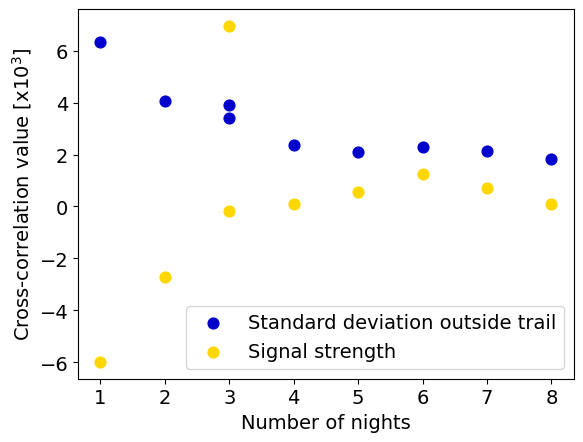

In [210]:
# PLOT NOISE AND SIGNAL VS NB OF TRANSITS
#----------------------------------------

std_dev_arr = np.array(std_dev_list) * 10e3
signal_str_arr = np.array(signal_str_list) * 10e3

plt.scatter(nb_transits_list, std_dev_arr, color="mediumblue", s=60, label="Standard deviation outside trail")
plt.scatter(nb_transits_list, signal_str_arr, color="gold", s=60, label="Signal strength")

plt.xlabel("Number of nights")
plt.ylabel("Cross-correlation value [x$10^{3}$]")
plt.legend()
plt.show()